# Proper Sharpe Ratio Inference

**Docker image**: `ml4t`

**Chapter 16: Strategy Simulation**
**Section Reference**: See Section 16.7 for strategy-level overfitting control

This notebook separates fixed-strategy Sharpe uncertainty from search adjustment.
It derives Probabilistic Sharpe Ratio (PSR), track-record requirements, and
autocorrelation-aware annualization before handing the multiple-testing problem
to Notebook 12.

**Objectives**

- Compute a fixed-strategy PSR with the correct one-sided tail probability
- Distinguish canonical MinTRL from a prospective 80%-power planning horizon
- Compare IID and Lo (2002) annualization on real SPY returns
- Show why selecting the best of many strategies requires DSR

**Prerequisites**: daily simple returns, annualized Sharpe ratios, and Section 16.7

## The Five Pitfalls of Naive Sharpe Analysis

1. **Independence/Normality assumptions** - Returns are autocorrelated and fat-tailed
2. **No significance testing** - Treating point estimates as ground truth
3. **Insufficient test power** - Not enough data to detect true effects
4. **P-value misinterpretation** - Confusing P(data|H0) with P(H0|data)
5. **Multiple testing** - Selection bias from testing many strategies

## Key Tools

| Method | Purpose | When to Use |
|--------|---------|-------------|
| **PSR** | Probabilistic Sharpe Ratio | Single strategy significance |
| **MinTRL** | Minimum Track Record Length | Confidence threshold |
| **Power planning** | Prospective sample requirement | Research design |
| **DSR** | Deflated Sharpe Ratio | Multiple strategy selection |
| **Lo annualization** | Serial-correlation-aware scaling | Dependent returns |

## References

- López de Prado et al. (2025). "How to Use the Sharpe Ratio". ADIA Lab.
- Bailey & López de Prado (2014). "The Deflated Sharpe Ratio"
- GitHub: https://github.com/zoonek/2025-sharpe-ratio

## Setup

In [1]:
"""Fixed-strategy Sharpe inference and track-record planning."""

# Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation.stats import (
    compute_min_trl,
)
from ml4t.diagnostic.evaluation.stats import (
    deflated_sharpe_ratio as lib_dsr,
)
from scipy.stats import norm

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title

In [2]:
# Production defaults - Papermill injects overrides after this cell
N_SIMULATIONS = 1000
SEED = 42

In [3]:
set_global_seeds(SEED)
rng = np.random.default_rng(SEED)
spy = load_etfs(symbols=["SPY"]).to_pandas()
spy = spy.set_index("timestamp").sort_index()
spy_returns = spy["close"].pct_change().dropna()
print(f"SPY data: {spy_returns.index[0]} to {spy_returns.index[-1]}")
print(f"Observations: {len(spy_returns)}")

SPY data: 2006-01-04 00:00:00 to 2025-12-31 00:00:00
Observations: 5030


## 1. The Sharpe Ratio Sampling Distribution

The Sharpe ratio is a **point estimate** with sampling uncertainty. For i.i.d.
normal returns at the native frequency:

$$\hat{SR} \sim \mathcal{N}\!\left(SR,\;\sqrt{\frac{1 + \tfrac{1}{2}SR^{2}}{T}}\right).$$

Real returns are non-normal *and* serially dependent, and both effects change
the standard error of $\widehat{SR}$. We separate the two adjustments:

1. **Non-normal i.i.d. (Mertens 2002).** With sample skewness $\gamma_3$ and
   kurtosis $\gamma_4$, the per-period variance is

   $$\text{Var}\bigl(\widehat{SR}\bigr) = \frac{1}{T}\!\left[1 - \gamma_3\,\widehat{SR} + \tfrac{\gamma_4 - 1}{4}\widehat{SR}^{\,2}\right].$$

   This is the asymptotic form. The implementation uses $T-1$ for the
   finite-sample Bessel correction in the PSR derivation.

2. **Autocorrelation-corrected annualization (Lo 2002, Eq. 17).** If we
   estimate $\widehat{SR}(1)$ at the native frequency, the annualized value
   is *not* $\sqrt{q}\,\widehat{SR}(1)$ when returns are autocorrelated. §4
   implements Lo's correction and shows the gap on real returns.

For the **combined** non-normal + AR(1) variance,
`ml4t.diagnostic.evaluation.stats.sharpe_inference.compute_sharpe_variance`
implements the López de Prado (2025) closed form; we benchmark against it
in §8.

In [4]:
def sharpe_ratio_variance(
    sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0, periods_per_year: int = 252
) -> float:
    """Return Mertens' iid, non-normal variance for annualized Sharpe.

    Autocorrelation is excluded. Use ``lo_2002_annualized_sharpe`` for
    serial-correlation-aware annualization or the library variance routine for
    the combined non-normal and AR(1) correction.
    """
    if n < 2:
        raise ValueError("Need at least 2 observations for Sharpe-ratio inference.")

    # Convert annualized SR to per-period SR for the Mertens formula.
    sr_period = sr / np.sqrt(periods_per_year)
    excess_kurtosis = kurtosis - 3

    # Finite-sample PSR variance uses n - 1 (Bessel correction).
    variance_numerator = 1 - sr_period * skewness + 0.25 * sr_period**2 * (excess_kurtosis + 2)
    if variance_numerator <= 0:
        raise ValueError("The estimated Sharpe-ratio variance must be positive.")
    var_period = variance_numerator / (n - 1)

    # Scale back to annualized: Var(SR_annual) = q * Var(SR_period)
    var_annual = var_period * periods_per_year
    return max(var_annual, 1e-10)

### Lo (2002) Autocorrelation-Corrected Annualization

Lo (2002, Eq. 17) shows that when returns are autocorrelated, the textbook
$\widehat{SR}(q) = \sqrt{q}\,\widehat{SR}(1)$ rule is wrong. With sample
autocorrelations $\hat\rho_k$, the annualized SR becomes

$$\widehat{SR}(q) = \widehat{SR}(1)\cdot
    \frac{q}{\sqrt{q + 2\sum_{k=1}^{q-1}(q-k)\hat\rho_k}}.$$

When all $\hat\rho_k = 0$ this collapses to $\sqrt{q}\,\widehat{SR}(1)$.
Positive autocorrelation inflates the denominator and pulls the annualized
Sharpe down; negative autocorrelation does the opposite. This is the
correct way to lift a daily Sharpe to an annual one when returns are not
i.i.d. In finite samples, estimating all $q-1$ autocorrelations is unstable,
so the implementation uses a Newey-West lag cutoff unless one is supplied.
We demonstrate it on real SPY returns in §4.

In [5]:
def _sample_autocorrelations(values: np.ndarray, max_lag: int) -> np.ndarray:
    """Return centered sample autocorrelations through ``max_lag``."""
    centered = values - values.mean()
    energy = float((centered**2).sum())
    return np.array(
        [float((centered[:-lag] * centered[lag:]).sum()) / energy for lag in range(1, max_lag + 1)]
    )

In [6]:
def lo_2002_annualized_sharpe(
    returns: pd.Series, periods_per_year: int = 252, max_lag: int | None = None
) -> dict:
    """Annualize Sharpe with Lo (2002, Eq. 17); default to a Newey-West lag."""
    r = pd.Series(returns).dropna().to_numpy()
    if r.size < 4:
        raise ValueError("Need at least 4 observations to estimate autocorrelations.")

    sr_period = float(r.mean() / r.std(ddof=1))
    q = int(periods_per_year)
    if q < 2:
        raise ValueError("periods_per_year must be at least 2.")
    if max_lag is None:
        max_lag = max(1, int(np.floor(4 * (r.size / 100) ** (2 / 9))))
    if max_lag < 1:
        raise ValueError("max_lag must be positive.")
    max_lag = min(max_lag, r.size - 2)

    rho = _sample_autocorrelations(r, max_lag)

    weights = np.array([q - k for k in range(1, max_lag + 1)], dtype=float)
    weighted_sum = float((weights * rho).sum())

    denom = q + 2.0 * weighted_sum
    if denom <= 0:
        raise ValueError("Lo annualization denominator is not positive for these returns.")
    multiplier = q / np.sqrt(denom)
    sr_annual_lo = sr_period * multiplier
    sr_annual_iid = sr_period * np.sqrt(q)

    return {
        "sr_period": sr_period,
        "sr_annual_iid": float(sr_annual_iid),
        "sr_annual_lo": float(sr_annual_lo),
        "annualization_multiplier_iid": float(np.sqrt(q)),
        "annualization_multiplier_lo": float(multiplier),
        "weighted_autocorrelation_sum": weighted_sum,
        "rho_lag1": float(rho[0]) if rho.size else 0.0,
        "max_lag": max_lag,
    }

### Standard Error Helper

Convert the Sharpe-ratio variance estimate into a standard error.

In [7]:
def sharpe_ratio_se(
    sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0, periods_per_year: int = 252
) -> float:
    """Standard error of annualized Sharpe ratio."""
    return np.sqrt(sharpe_ratio_variance(sr, n, skewness, kurtosis, periods_per_year))

In [8]:
# Demonstrate sampling distribution
true_sr = 0.5
n_samples = 252

# Simulate Sharpe ratio estimates
simulated_srs = []
for _ in range(N_SIMULATIONS):
    # Generate returns with true annualized SR = 0.5 (assuming 15% annual vol)
    daily_vol = 0.15 / np.sqrt(252)
    daily_mean = true_sr * 0.15 / 252  # Annual mean = SR * annual_vol, then / 252
    returns = rng.normal(daily_mean, daily_vol, n_samples)

    # Compute observed SR
    obs_sr = np.mean(returns) / np.std(returns, ddof=1) * np.sqrt(252)
    simulated_srs.append(obs_sr)

simulated_srs = np.array(simulated_srs)

# Compare with theoretical distribution
theoretical_se = sharpe_ratio_se(true_sr, n_samples)

print("=== Sharpe Ratio Sampling Distribution ===")
print(f"\nTrue SR: {true_sr}")
print(f"Sample size: {n_samples}")
print(f"\nSimulated mean: {np.mean(simulated_srs):.3f}")
print(f"Simulated std: {np.std(simulated_srs, ddof=1):.3f}")
print(f"Theoretical SE: {theoretical_se:.3f}")

=== Sharpe Ratio Sampling Distribution ===

True SR: 0.5
Sample size: 252

Simulated mean: 0.499
Simulated std: 1.000
Theoretical SE: 1.002


In [9]:
def _style_sampling_distribution(ax) -> None:
    """Apply reference lines, labels, and the message title."""
    ax.axvline(
        true_sr,
        color=COLORS["positive"],
        linestyle="--",
        lw=2,
        label=f"True SR = {true_sr}",
    )
    ax.axvline(0, color=COLORS["neutral"], linestyle=":", alpha=0.6)
    ax.set_xlabel("Sharpe Ratio")
    ax.set_ylabel("Density")
    add_message_title(
        ax,
        "One Trading Year Leaves Wide Sharpe Uncertainty",
        subtitle=f"Monte Carlo sampling distribution, true annualized SR = {true_sr}, n = {n_samples}",
    )
    ax.set_title(
        ax.get_title(loc="left"), loc="left", color=COLORS["blue"], fontweight="bold", pad=15
    )
    ax.legend()
    sns.despine()

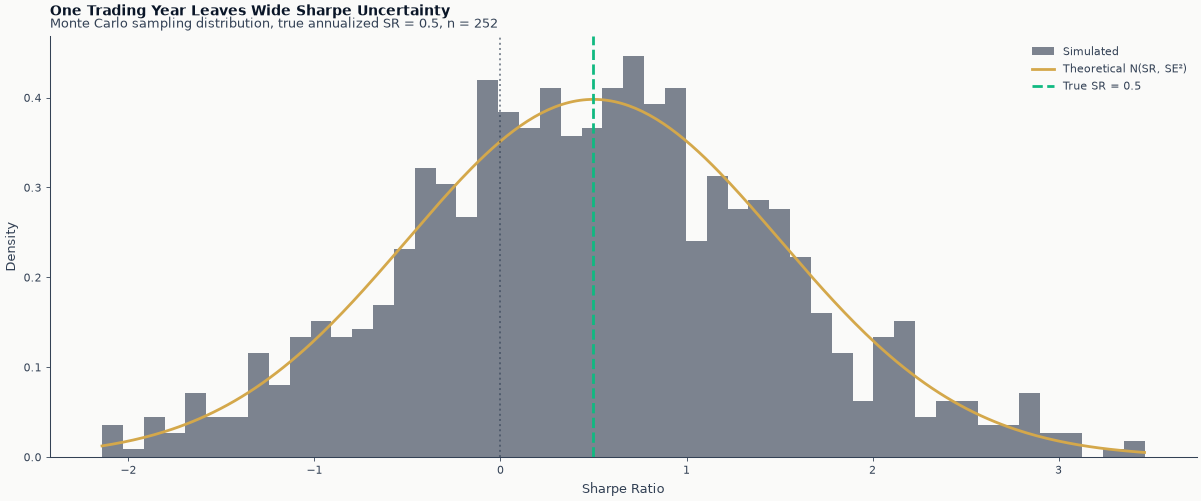

In [10]:
# Plot sampling distribution
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    simulated_srs,
    bins=50,
    density=True,
    alpha=0.55,
    color=COLORS["blue_light"],
    label="Simulated",
)

x = np.linspace(simulated_srs.min(), simulated_srs.max(), 300)
theoretical_pdf = norm.pdf(x, loc=true_sr, scale=theoretical_se)
ax.plot(x, theoretical_pdf, color=COLORS["amber"], lw=2, label="Theoretical N(SR, SE²)")
_style_sampling_distribution(ax)
plt.show()

## 2. Probabilistic Sharpe Ratio (PSR)

PSR answers: **What is the probability that the true SR exceeds a benchmark?**

$$PSR(\hat{SR}, SR^*) = \Phi\left(\frac{\hat{SR} - SR^*}{\hat{\sigma}(\hat{SR})}\right)$$

where $SR^*$ is the benchmark (often 0 or the risk-free rate).

In [11]:
def probabilistic_sharpe_ratio(
    observed_sr: float, benchmark_sr: float, n: int, skewness: float = 0.0, kurtosis: float = 3.0
) -> dict:
    """Return one-sided PSR inference against an annualized benchmark.

    The variance incorporates sample size, skewness, and Pearson kurtosis.
    """
    if not np.isfinite(observed_sr) or not np.isfinite(benchmark_sr):
        raise ValueError("Sharpe ratios must be finite.")
    se = sharpe_ratio_se(observed_sr, n, skewness, kurtosis)
    z_score = (observed_sr - benchmark_sr) / se
    psr = norm.cdf(z_score)

    one_sided_p_value = 1 - psr
    two_sided_p_value = 2 * min(psr, 1 - psr)

    return {
        "psr": psr,
        "z_score": z_score,
        "standard_error": se,
        "p_value": one_sided_p_value,
        "p_value_two_sided": two_sided_p_value,
        "ci_95_lower": observed_sr - 1.96 * se,
        "ci_95_upper": observed_sr + 1.96 * se,
    }

In [12]:
# Example: Evaluate a strategy
observed_sr = 1.2
n_obs = 252  # 1 year
benchmark = 0  # Test against zero

psr_result = probabilistic_sharpe_ratio(observed_sr, benchmark, n_obs)

print("=== Probabilistic Sharpe Ratio ===")
print(f"\nObserved SR: {observed_sr}")
print(f"Sample size: {n_obs} days")
print(f"Benchmark: {benchmark}")
print(f"\nPSR (P(true SR > {benchmark})): {psr_result['psr']:.1%}")
print(f"Z-score: {psr_result['z_score']:.2f}")
print(f"P-value (one-sided): {psr_result['p_value']:.4f}")
print(f"P-value (two-sided): {psr_result['p_value_two_sided']:.4f}")
print(f"95% CI: [{psr_result['ci_95_lower']:.2f}, {psr_result['ci_95_upper']:.2f}]")

=== Probabilistic Sharpe Ratio ===

Observed SR: 1.2
Sample size: 252 days
Benchmark: 0

PSR (P(true SR > 0)): 88.4%
Z-score: 1.20
P-value (one-sided): 0.1159
P-value (two-sided): 0.2317
95% CI: [-0.77, 3.17]


In [13]:
# Show how PSR varies with sample size
sample_sizes = [63, 126, 252, 504, 756, 1008]  # 3m to 4y
observed_sr = 0.8

**PSR sensitivity to sample size** (observed SR = 0.8):

In [14]:
psr_rows = []
for n in sample_sizes:
    result = probabilistic_sharpe_ratio(observed_sr, 0, n)
    psr_rows.append(
        {
            "days": n,
            "years": n / 252,
            "standard_error": result["standard_error"],
            "psr": result["psr"],
            "ci_95_lower": result["ci_95_lower"],
            "ci_95_upper": result["ci_95_upper"],
        }
    )

pl.DataFrame(psr_rows)

days,years,standard_error,psr,ci_95_lower,ci_95_upper
i64,f64,f64,f64,f64,f64
63,0.25,2.017344,0.654154,-3.153995,4.753995
126,0.5,1.42076,0.713309,-1.98469,3.58469
252,1.0,1.002626,0.787537,-1.165147,2.765147
504,2.0,0.708259,0.870663,-0.588187,2.188187
756,3.0,0.578099,0.916797,-0.333074,1.933074
1008,4.0,0.500566,0.945,-0.181109,1.781109


## 3. Minimum Track Record Length (MinTRL)

MinTRL answers: **How much data is needed to exceed a benchmark at a chosen confidence?**

Given an observed SR and significance level, canonical MinTRL computes the
minimum observations needed. A separate prospective planning calculation adds
a power target before data are collected.

Let $SR_p = SR_{ann}/\sqrt{q}$ denote Sharpe at the return series' native
frequency, where $q$ is periods per year. Canonical finite-sample MinTRL is

$$T_{min} = 1 +
\frac{z_{1-\alpha}^{2}\left[1-\gamma_3SR_p+
\frac{\gamma_4-1}{4}SR_p^2\right]}{(SR_p-SR_p^*)^2}.$$

For prospective planning with $SR_p^*=0$ and normal returns, the same
per-period Sharpe units give:

$$T_\text{plan} \approx
\frac{(z_{1-\alpha}+z_{1-\beta})^2\left(1 + 0.5SR_p^2\right)}{SR_p^2}.$$

In [15]:
def _validate_mintrl_inputs(
    target_sr: float, benchmark_sr: float, alpha: float, power: float, periods_per_year: int
) -> None:
    """Reject invalid track-record planning inputs."""
    if target_sr <= benchmark_sr:
        raise ValueError("target_sr must exceed benchmark_sr.")
    if not 0 < alpha < 1:
        raise ValueError("alpha must lie strictly between 0 and 1.")
    if not 0 < power < 1:
        raise ValueError("power must lie strictly between 0 and 1.")
    if periods_per_year < 1:
        raise ValueError("periods_per_year must be positive.")

In [16]:
def minimum_track_record_length(
    target_sr: float,
    benchmark_sr: float = 0,
    alpha: float = 0.05,
    power: float = 0.80,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    periods_per_year: int = 252,
) -> dict:
    """Return canonical MinTRL and a prospective power-planning horizon."""
    _validate_mintrl_inputs(target_sr, benchmark_sr, alpha, power, periods_per_year)

    z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)

    sr_period = target_sr / np.sqrt(periods_per_year)
    bench_period = benchmark_sr / np.sqrt(periods_per_year)
    excess_kurtosis = kurtosis - 3

    # Per-period variance numerator
    numer = 1 - sr_period * skewness + 0.25 * sr_period**2 * (excess_kurtosis + 2)
    sr_diff = sr_period - bench_period

    # Canonical finite-sample MinTRL includes the Bessel-correction offset.
    min_trl_sig = 1 + z_alpha**2 * numer / (sr_diff**2)

    # The chapter's prospective large-sample planning approximation adds the
    # desired-power quantile. It is a design target, not a second p-value test.
    planning_length = (z_alpha + z_beta) ** 2 * numer / (sr_diff**2)

    return {
        "min_trl_significance": int(np.ceil(min_trl_sig)),
        "planning_length_with_power": int(np.ceil(planning_length)),
        "target_sr": target_sr,
        "benchmark_sr": benchmark_sr,
        "alpha": alpha,
        "power": power,
        "z_alpha": z_alpha,
        "z_beta": z_beta,
    }

In [17]:
# MinTRL for different Sharpe ratios

**Track-record requirements** (canonical MinTRL and 80%-power planning horizon):

In [18]:
mintrl_rows = []
for sr in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]:
    result = minimum_track_record_length(sr)
    mintrl_rows.append(
        {
            "target_sr": sr,
            "min_trl_significance_days": result["min_trl_significance"],
            "planning_length_days": result["planning_length_with_power"],
            "planning_length_years": result["planning_length_with_power"] / 252,
        }
    )
pl.DataFrame(mintrl_rows)

target_sr,min_trl_significance_days,planning_length_days,planning_length_years
f64,i64,i64,f64
0.3,7578,17315,68.710317
0.5,2730,6236,24.746032
0.8,1068,2438,9.674603
1.0,685,1562,6.198413
1.5,306,696,2.761905
2.0,173,393,1.559524


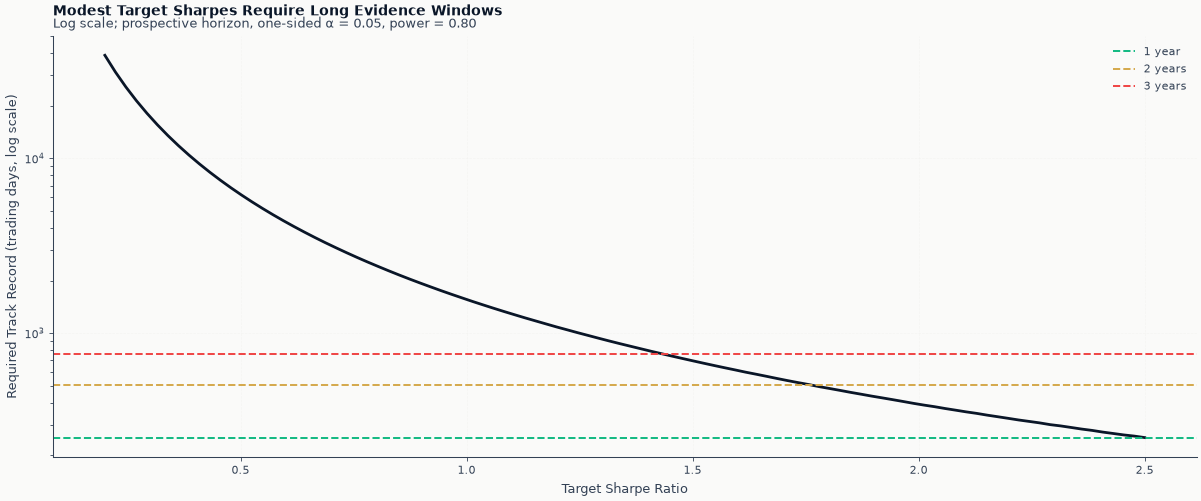


Planning result: a target annualized SR of 0.5 needs 24.7 years for 80% power.


In [19]:
# Visualize MinTRL
sr_range = np.linspace(0.2, 2.5, 100)
min_trl_values = [minimum_track_record_length(sr)["planning_length_with_power"] for sr in sr_range]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sr_range, min_trl_values, color=COLORS["blue"], lw=2)
ax.axhline(252, color=COLORS["positive"], linestyle="--", label="1 year")
ax.axhline(504, color=COLORS["amber"], linestyle="--", label="2 years")
ax.axhline(756, color=COLORS["negative"], linestyle="--", label="3 years")

ax.set_xlabel("Target Sharpe Ratio")
ax.set_ylabel("Required Track Record (trading days, log scale)")
add_message_title(
    ax,
    "Modest Target Sharpes Require Long Evidence Windows",
    subtitle="Log scale; prospective horizon, one-sided α = 0.05, power = 0.80",
)
ax.set_title(
    ax.get_title(loc="left"),
    loc="left",
    color=COLORS["blue"],
    fontweight="bold",
    pad=15,
)
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
sns.despine()
plt.show()

sr_05 = minimum_track_record_length(0.5)
print(
    "\nPlanning result: a target annualized SR of 0.5 needs "
    f"{sr_05['planning_length_with_power'] / 252:.1f} years for 80% power."
)

## 4. Non-Normality and Autocorrelation Adjustments

Real returns have:
- **Negative skewness** (crash risk)
- **Excess kurtosis** (fat tails)
- **Autocorrelation** (momentum/mean reversion)

The skew/kurtosis effects enter the Sharpe **variance** through the Mertens
(2002) formula in §1 (`sharpe_ratio_variance`); we propagate them through
PSR in the table below. Autocorrelation enters separately, through Lo
(2002, Eq. 17) annualization - a wedge between the textbook
$\sqrt{q}\,\widehat{SR}(1)$ rule and the autocorrelation-corrected value.
We measure both on real SPY returns.

In [20]:
def compute_return_moments(returns: pd.Series) -> dict:
    """Compute mean, std, skewness, kurtosis of returns."""
    from scipy.stats import kurtosis, skew

    return {
        "mean": returns.mean(),
        "std": returns.std(),
        "skewness": skew(returns),
        "kurtosis": kurtosis(returns, fisher=False),  # Regular kurtosis (3 for normal)
        "excess_kurtosis": kurtosis(returns),  # Excess kurtosis (0 for normal)
        "sharpe": returns.mean() / returns.std() * np.sqrt(252),
    }

In [21]:
# Analyze real return moments
spy_2020_2023 = spy_returns.loc["2020":"2023"]
moments = compute_return_moments(spy_2020_2023)

print("=== SPY Return Moments (2020-2023) ===")
for key, value in moments.items():
    print(f"{key:20}: {value:.4f}")

=== SPY Return Moments (2020-2023) ===
mean                : 0.0006
std                 : 0.0142
skewness            : -0.5100
kurtosis            : 13.2978
excess_kurtosis     : 10.2978
sharpe              : 0.6151


In [22]:
# Compare PSR with and without non-normality adjustment
observed_sr = moments["sharpe"]
n = len(spy_2020_2023)

# Normal assumption
psr_normal = probabilistic_sharpe_ratio(observed_sr, 0, n, skewness=0, kurtosis=3)

# Adjusted for actual moments
psr_adjusted = probabilistic_sharpe_ratio(
    observed_sr, 0, n, skewness=moments["skewness"], kurtosis=moments["kurtosis"]
)

**PSR comparison: normal vs skew/kurtosis-adjusted** (observed SR / sample
size shown above). Note: this comparison adjusts for *non-normality* only;
the autocorrelation correction enters separately via Lo (2002)
annualization, demonstrated immediately below.

In [23]:
pl.DataFrame(
    {
        "metric": [
            "Standard error",
            "PSR",
            "One-sided p-value",
            "95% CI lower",
            "95% CI upper",
        ],
        "normal": [
            psr_normal["standard_error"],
            psr_normal["psr"],
            psr_normal["p_value"],
            psr_normal["ci_95_lower"],
            psr_normal["ci_95_upper"],
        ],
        "adjusted": [
            psr_adjusted["standard_error"],
            psr_adjusted["psr"],
            psr_adjusted["p_value"],
            psr_adjusted["ci_95_lower"],
            psr_adjusted["ci_95_upper"],
        ],
    }
)

metric,normal,adjusted
str,f64,f64
"""Standard error""",0.500934,0.506813
"""PSR""",0.890274,0.887577
"""One-sided p-value""",0.109726,0.112423
"""95% CI lower""",-0.366689,-0.378213
"""95% CI upper""",1.596971,1.608494


### Lo (2002) Annualization on Real SPY Returns

Apply `lo_2002_annualized_sharpe` to the SPY 2020-2023 series. The textbook
IID rule reports $\sqrt{252}\,\widehat{SR}(1)$; Lo's correction adds the
weighted-autocorrelation term in the denominator. The difference between
the two annualizations is the autocorrelation wedge the chapter §16.7
narrative warns about.

In [24]:
lo_result = lo_2002_annualized_sharpe(spy_2020_2023, periods_per_year=252)
pl.DataFrame(
    {
        "quantity": [
            "Native (daily) SR",
            "Annualized SR - IID (sqrt(q) rule)",
            "Annualized SR - Lo (2002, Eq. 17)",
            "Annualization multiplier - IID",
            "Annualization multiplier - Lo",
            f"Sum_{{k=1}}^{{{lo_result['max_lag']}}}(q-k) * rho_k",
            "rho at lag 1",
        ],
        "value": [
            lo_result["sr_period"],
            lo_result["sr_annual_iid"],
            lo_result["sr_annual_lo"],
            lo_result["annualization_multiplier_iid"],
            lo_result["annualization_multiplier_lo"],
            lo_result["weighted_autocorrelation_sum"],
            lo_result["rho_lag1"],
        ],
    }
)

quantity,value
str,f64
"""Native (daily) SR""",0.03875
"""Annualized SR - IID (sqrt(q) r…",0.615141
"""Annualized SR - Lo (2002, Eq. …",0.8396
"""Annualization multiplier - IID""",15.874508
"""Annualization multiplier - Lo""",21.666965
"""Sum_{k=1}^{6}(q-k) * rho_k""",-58.364464
"""rho at lag 1""",-0.172794


**Reading the table.** The Lo annualization multiplier need not equal
$\sqrt{252}$. Positive weighted autocorrelation pulls the annualized Sharpe
down relative to the IID rule because variance accumulates faster; negative
weighted autocorrelation pushes it up. The sign and magnitude of the wedge
are computed from the truncated weighted sum shown above.

### Five-year SR = 1.0 CI Example

A concrete reference point cited in §16.7: a strategy reports
$\widehat{SR}_\text{annual} = 1.0$ on 5 years of daily data. What is the
95% confidence interval? We compute the SE under both the normal and
observed-moments assumptions, and report the resulting interval.

In [25]:
_sr_target = 1.0
_n_5y = 252 * 5
_psr_normal_5y = probabilistic_sharpe_ratio(_sr_target, 0, _n_5y, skewness=0.0, kurtosis=3.0)
_psr_actual_5y = probabilistic_sharpe_ratio(
    _sr_target, 0, _n_5y, skewness=moments["skewness"], kurtosis=moments["kurtosis"]
)
pl.DataFrame(
    {
        "assumption": ["IID normal", "Mertens skew/kurt (SPY moments)"],
        "standard_error": [_psr_normal_5y["standard_error"], _psr_actual_5y["standard_error"]],
        "ci_95_lower": [_psr_normal_5y["ci_95_lower"], _psr_actual_5y["ci_95_lower"]],
        "ci_95_upper": [_psr_normal_5y["ci_95_upper"], _psr_actual_5y["ci_95_upper"]],
        "ci_width": [
            _psr_normal_5y["ci_95_upper"] - _psr_normal_5y["ci_95_lower"],
            _psr_actual_5y["ci_95_upper"] - _psr_actual_5y["ci_95_lower"],
        ],
    }
)

assumption,standard_error,ci_95_lower,ci_95_upper,ci_width
str,f64,f64,f64,f64
"""IID normal""",0.447835,0.122244,1.877756,1.755512
"""Mertens skew/kurt (SPY moments…",0.4572,0.103888,1.896112,1.792224


## 5. IID Mertens PSR Inference Framework

This framework reports an IID Mertens PSR verdict. The Lo-adjusted Sharpe is displayed as a
dependence-aware diagnostic, but it does not determine the significance status below.

In [26]:
def _sharpe_sample_statistics(returns: pd.Series) -> tuple[pd.Series, int, float, float, float]:
    """Return cleaned observations and their Sharpe-distribution inputs."""
    from scipy.stats import kurtosis, skew

    clean = pd.Series(returns).dropna()
    if len(clean) < 4:
        raise ValueError("Need at least 4 finite returns for complete Sharpe inference.")
    std_ret = clean.std(ddof=1)
    if std_ret <= 0:
        raise ValueError("Return standard deviation must be positive.")
    observed_sr = clean.mean() / std_ret * np.sqrt(252)
    return clean, len(clean), observed_sr, skew(clean), kurtosis(clean, fisher=False)

In [27]:
def _observed_mintrl(
    observed_sr: float,
    benchmark_sr: float,
    alpha: float,
    skewness: float,
    kurtosis: float,
) -> dict:
    """Return canonical MinTRL or infinities below the benchmark."""
    if observed_sr <= benchmark_sr:
        return {
            "min_trl_significance": np.inf,
            "planning_length_with_power": np.inf,
        }
    return minimum_track_record_length(
        observed_sr,
        benchmark_sr,
        alpha=alpha,
        power=0.80,
        skewness=skewness,
        kurtosis=kurtosis,
    )

In [28]:
def complete_sharpe_inference(
    returns: pd.Series, benchmark_sr: float = 0, alpha: float = 0.05
) -> dict:
    """Combine fixed-strategy PSR, MinTRL, and Lo annualization.

    Selection adjustment remains the separate DSR layer in Notebook 12.
    """
    clean, n, observed_sr, skew_val, kurt_val = _sharpe_sample_statistics(returns)
    psr_result = probabilistic_sharpe_ratio(observed_sr, benchmark_sr, n, skew_val, kurt_val)
    mintrl_result = _observed_mintrl(observed_sr, benchmark_sr, alpha, skew_val, kurt_val)
    lo_block = lo_2002_annualized_sharpe(clean, periods_per_year=252)
    is_significant_psr = psr_result["p_value"] < alpha
    has_sufficient_data = n >= mintrl_result.get("min_trl_significance", np.inf)
    iid_mertens_inference_status = "SIGNIFICANT" if is_significant_psr else "NOT SIGNIFICANT"

    return {
        "n_observations": n,
        "observed_sr_iid": observed_sr,
        "observed_sr_lo": lo_block["sr_annual_lo"],
        "annualization_multiplier_lo": lo_block["annualization_multiplier_lo"],
        "weighted_autocorrelation_sum": lo_block["weighted_autocorrelation_sum"],
        "skewness": skew_val,
        "kurtosis": kurt_val,
        "psr": psr_result["psr"],
        "psr_p_value": psr_result["p_value"],
        "ci_95": (psr_result["ci_95_lower"], psr_result["ci_95_upper"]),
        "min_trl": mintrl_result.get("min_trl_significance", np.inf),
        "planning_length_80pct_power": mintrl_result.get("planning_length_with_power", np.inf),
        "has_sufficient_data": has_sufficient_data,
        "iid_mertens_inference_status": iid_mertens_inference_status,
        "iid_mertens_p_value": psr_result["p_value"],
    }

In [29]:
# Apply to SPY
spy_inference = complete_sharpe_inference(spy_2020_2023, benchmark_sr=0)

print("=== Complete Sharpe Ratio Inference: SPY (2020-2023) ===")
print("\n--- Basic Statistics ---")
print(f"Observations:                       {spy_inference['n_observations']}")
print(f"Observed annualized SR (IID rule):  {spy_inference['observed_sr_iid']:.3f}")
print(f"Observed annualized SR (Lo 2002):   {spy_inference['observed_sr_lo']:.3f}")
print(f"Lo annualization multiplier:        {spy_inference['annualization_multiplier_lo']:.3f}")
print(f"Skewness:                           {spy_inference['skewness']:.3f}")
print(f"Kurtosis:                           {spy_inference['kurtosis']:.2f}")

print("\n--- Probabilistic Sharpe Ratio ---")
print(f"PSR (P(true SR > 0)): {spy_inference['psr']:.1%}")
print(f"One-sided p-value: {spy_inference['psr_p_value']:.4f}")
print(f"95% CI: [{spy_inference['ci_95'][0]:.3f}, {spy_inference['ci_95'][1]:.3f}]")

print("\n--- Power Analysis ---")
print(f"MinTRL (days): {spy_inference['min_trl']}")
print(f"MinTRL (years): {spy_inference['min_trl'] / 252:.1f}")
print(f"Has sufficient data: {spy_inference['has_sufficient_data']}")

print(f"\nIID Mertens PSR inference outcome: {spy_inference['iid_mertens_inference_status']}")

=== Complete Sharpe Ratio Inference: SPY (2020-2023) ===

--- Basic Statistics ---
Observations:                       1006
Observed annualized SR (IID rule):  0.615
Observed annualized SR (Lo 2002):   0.840
Lo annualization multiplier:        21.667
Skewness:                           -0.510
Kurtosis:                           13.30

--- Probabilistic Sharpe Ratio ---
PSR (P(true SR > 0)): 88.8%
One-sided p-value: 0.1124
95% CI: [-0.378, 1.608]

--- Power Analysis ---
MinTRL (days): 1847
MinTRL (years): 7.3
Has sufficient data: False

IID Mertens PSR inference outcome: NOT SIGNIFICANT


## 6. Case Study: Simulated Strategy Selection

Demonstrate the full framework when selecting from multiple strategies.

In [30]:
# Simulate testing 30 strategy variants
selection_rng = np.random.default_rng(123)

n_strategies = 30
n_days = 504  # 2 years

# Generate strategies: 5 have true SR = 0.8, rest have SR = 0
true_sr_values = selection_rng.permutation([0.8] * 5 + [0.0] * (n_strategies - 5)).tolist()

strategy_returns = {}
for i, true_sr in enumerate(true_sr_values):
    daily_vol = 0.15 / np.sqrt(252)
    daily_mean = true_sr * 0.15 / 252  # Annual mean = SR * annual_vol, then / 252
    returns = selection_rng.normal(daily_mean, daily_vol, n_days)
    strategy_returns[f"Strategy_{i + 1}"] = pd.Series(returns)

# Calculate observed Sharpe ratios
observed_sharpes = {
    name: (rets.mean() / rets.std(ddof=1) * np.sqrt(252), true_sr_values[i])
    for i, (name, rets) in enumerate(strategy_returns.items())
}

# Sort by observed SR
sorted_strategies = sorted(observed_sharpes.items(), key=lambda x: -x[1][0])

**Strategy-selection scenario.** The generated experiment contains:

In [31]:
display(
    Markdown(
        f"30 strategies tested: 5 true signals (SR = 0.8), 25 nulls "
        f"(SR = 0), {n_days} days each. Top 10 by observed SR:"
    )
)

30 strategies tested: 5 true signals (SR = 0.8), 25 nulls (SR = 0), 504 days each. Top 10 by observed SR:

In [32]:
top10 = pl.DataFrame(
    [
        {
            "strategy": name,
            "observed_sr": obs_sr,
            "true_sr": true_sr,
            "is_real": "YES" if true_sr > 0 else "no",
        }
        for name, (obs_sr, true_sr) in sorted_strategies[:10]
    ]
)
top10

strategy,observed_sr,true_sr,is_real
str,f64,f64,str
"""Strategy_14""",2.267623,0.8,"""YES"""
"""Strategy_30""",1.791615,0.0,"""no"""
"""Strategy_19""",1.730556,0.0,"""no"""
"""Strategy_12""",1.600338,0.8,"""YES"""
"""Strategy_7""",1.260402,0.8,"""YES"""
"""Strategy_2""",0.879465,0.0,"""no"""
"""Strategy_1""",0.79068,0.8,"""YES"""
"""Strategy_28""",0.750121,0.8,"""YES"""
"""Strategy_27""",0.747762,0.0,"""no"""


In [33]:
# Apply complete per-strategy inference to the "best" strategy. PSR alone
# does not know about the selection process; it asks "does this single
# return series look like skill?" - and on a series cherry-picked as the
# top of a 30-strategy search, it can answer "yes" even when the true SR is
# zero. Notebook 12 (`12_dsr_validation`) shows the multiple-testing
# correction; here we just show that PSR by itself is insufficient.
best_name, (best_sr, best_true_sr) = sorted_strategies[0]
best_returns = strategy_returns[best_name]

inference_result = complete_sharpe_inference(best_returns, benchmark_sr=0, alpha=0.05)

print(f"\n=== Per-strategy inference: '{best_name}' (selected from 30) ===")
print(f"\nTrue SR (hidden ground truth): {best_true_sr:.1f}")
print(f"Observed annualized SR (IID rule):   {inference_result['observed_sr_iid']:.3f}")
print(f"Observed annualized SR (Lo 2002):    {inference_result['observed_sr_lo']:.3f}")
print(f"Lo annualization multiplier:         {inference_result['annualization_multiplier_lo']:.3f}")

print("\n--- Single-strategy view (PSR) ---")
print(f"PSR (P(true SR > 0)): {inference_result['psr']:.1%}")
print(f"One-sided p-value: {inference_result['psr_p_value']:.4f}")
print(f"95% CI: [{inference_result['ci_95'][0]:.3f}, {inference_result['ci_95'][1]:.3f}]")

print(
    "\nPer-strategy IID Mertens PSR inference outcome: "
    f"{inference_result['iid_mertens_inference_status']}"
)
print(
    "\nNote: this verdict ignores the 29 other strategies that lost the "
    "selection contest. Notebook 12 applies the DSR correction; the case-"
    "study cohort_metrics table reports DSR for production strategies."
)


=== Per-strategy inference: 'Strategy_14' (selected from 30) ===

True SR (hidden ground truth): 0.8
Observed annualized SR (IID rule):   2.268
Observed annualized SR (Lo 2002):    2.613
Lo annualization multiplier:         18.292

--- Single-strategy view (PSR) ---
PSR (P(true SR > 0)): 99.9%
One-sided p-value: 0.0007
95% CI: [0.883, 3.652]

Per-strategy IID Mertens PSR inference outcome: SIGNIFICANT

Note: this verdict ignores the 29 other strategies that lost the selection contest. Notebook 12 applies the DSR correction; the case-study cohort_metrics table reports DSR for production strategies.


## 7. Practical Workflow Summary

### Before Backtesting

1. **Define target SR**: What SR would make the strategy worthwhile?
2. **Plan statistical power**: Do you have enough data for the target effect?
3. **Plan for multiple testing**: How many variants will you test?

### After Backtesting

1. **Calculate observed SR** with confidence intervals (PSR)
2. **Adjust for non-normality** using actual skewness/kurtosis
3. **Correct for multiple testing** if you tested multiple strategies (DSR)
4. **Compare with canonical MinTRL**: Does the observed effect clear its confidence gate?

In [34]:
def _print_checklist_statistics(inference: dict) -> None:
    """Print the sample and return-distribution sections."""
    print("\n[1] BASIC STATISTICS")
    print(f"    Observations:        {inference['n_observations']}")
    print(f"    SR (IID rule):       {inference['observed_sr_iid']:.3f}")
    print(f"    SR (Lo 2002, Eq.17): {inference['observed_sr_lo']:.3f}")
    print(
        f"    Lo annualizer:       {inference['annualization_multiplier_lo']:.3f}"
        f"   (sqrt(252) = 15.875)"
    )
    print(f"    95% CI (PSR):        [{inference['ci_95'][0]:.3f}, {inference['ci_95'][1]:.3f}]")

    print("\n[2] RETURN DISTRIBUTION")
    skew_flag = "near-normal" if abs(inference["skewness"]) < 0.5 else "non-normal"
    kurt_flag = "near-normal" if abs(inference["kurtosis"] - 3) < 1 else "fat tails"
    print(f"    Skewness:         {inference['skewness']:.3f}  ({skew_flag})")
    print(f"    Kurtosis:         {inference['kurtosis']:.2f}   ({kurt_flag})")

In [35]:
def _print_checklist_planning(
    inference: dict, mintrl: dict, target_sr: float, alpha: float
) -> None:
    """Print prospective planning and fixed-strategy PSR sections."""
    print("\n[3] PROSPECTIVE POWER PLANNING")
    print(f"    Target SR:        {target_sr:.2f}")
    print(
        f"    Planning length:  {mintrl['planning_length_with_power']} days "
        f"({mintrl['planning_length_with_power'] / 252:.1f} years)"
    )
    sufficient = inference["n_observations"] >= mintrl["planning_length_with_power"]
    shortfall = mintrl["planning_length_with_power"] - inference["n_observations"]
    suffix = "sufficient" if sufficient else f"shortfall {shortfall} days"
    print(f"    Current data:     {inference['n_observations']} days  ({suffix})")

    print("\n[4] PER-STRATEGY PSR")
    psr_flag = "below alpha" if inference["psr_p_value"] < alpha else "above alpha"
    print(f"    PSR:              {inference['psr']:.1%}")
    print(f"    One-sided p:      {inference['psr_p_value']:.4f}  ({psr_flag})")

In [36]:
def sharpe_ratio_checklist(returns: pd.Series, target_sr: float, alpha: float = 0.05) -> None:
    """Print a single-strategy Sharpe inference checklist (PSR + MinTRL + Lo).

    For the selection-bias (multiple-testing) layer, see Notebook 12.
    """
    inference = complete_sharpe_inference(returns, benchmark_sr=0, alpha=alpha)
    mintrl = minimum_track_record_length(target_sr, alpha=alpha, power=0.80)

    print("=" * 60)
    print("SHARPE RATIO INFERENCE CHECKLIST (single strategy)")
    print("=" * 60)
    _print_checklist_statistics(inference)
    _print_checklist_planning(inference, mintrl, target_sr, alpha)
    print("\n" + "=" * 60)
    print(
        "Per-strategy IID Mertens PSR inference outcome: "
        f"{inference['iid_mertens_inference_status']}"
    )
    print("For selection bias across candidate strategies, see Notebook 12.")
    print("=" * 60)

In [37]:
# Run checklist on SPY
sharpe_ratio_checklist(spy_2020_2023, target_sr=0.5)

SHARPE RATIO INFERENCE CHECKLIST (single strategy)

[1] BASIC STATISTICS
    Observations:        1006
    SR (IID rule):       0.615
    SR (Lo 2002, Eq.17): 0.840
    Lo annualizer:       21.667   (sqrt(252) = 15.875)
    95% CI (PSR):        [-0.378, 1.608]

[2] RETURN DISTRIBUTION
    Skewness:         -0.510  (non-normal)
    Kurtosis:         13.30   (fat tails)

[3] PROSPECTIVE POWER PLANNING
    Target SR:        0.50
    Planning length:  6236 days (24.7 years)
    Current data:     1006 days  (shortfall 5230 days)

[4] PER-STRATEGY PSR
    PSR:              88.8%
    One-sided p:      0.1124  (above alpha)

Per-strategy IID Mertens PSR inference outcome: NOT SIGNIFICANT
For selection bias across candidate strategies, see Notebook 12.


In [38]:
# Run checklist on simulated "best" strategy (note: PSR alone misses the
# 30-strategy selection contest - Notebook 12 demonstrates the DSR correction
# that would deflate this Sharpe).
print("\n")
sharpe_ratio_checklist(best_returns, target_sr=0.8)



SHARPE RATIO INFERENCE CHECKLIST (single strategy)

[1] BASIC STATISTICS
    Observations:        504
    SR (IID rule):       2.268
    SR (Lo 2002, Eq.17): 2.613
    Lo annualizer:       18.292   (sqrt(252) = 15.875)
    95% CI (PSR):        [0.883, 3.652]

[2] RETURN DISTRIBUTION
    Skewness:         0.108  (near-normal)
    Kurtosis:         3.15   (near-normal)

[3] PROSPECTIVE POWER PLANNING
    Target SR:        0.80
    Planning length:  2438 days (9.7 years)
    Current data:     504 days  (shortfall 1934 days)

[4] PER-STRATEGY PSR
    PSR:              99.9%
    One-sided p:      0.0007  (below alpha)

Per-strategy IID Mertens PSR inference outcome: SIGNIFICANT
For selection bias across candidate strategies, see Notebook 12.


**Prospective planning summary** (80% power, α=0.05):

In [39]:
mintrl_summary = pl.DataFrame(
    [
        {
            "target_sr": sr_val,
            "planning_days": minimum_track_record_length(sr_val)["planning_length_with_power"],
            "planning_years": minimum_track_record_length(sr_val)["planning_length_with_power"]
            / 252,
        }
        for sr_val in [0.3, 0.5, 0.8, 1.0, 1.5]
    ]
)
mintrl_summary

target_sr,planning_days,planning_years
f64,i64,f64
0.3,17315,68.710317
0.5,6236,24.746032
0.8,2438,9.674603
1.0,1562,6.198413
1.5,696,2.761905


**Sharpe-ratio 95% CI half-width** (SR=0.5) by sample size:

In [40]:
ci_width_rows = []
for n_ci in [126, 252, 504, 1260]:
    se_ci = sharpe_ratio_se(0.5, n_ci)
    ci_width_rows.append({"days": n_ci, "ci_half_width": 1.96 * se_ci})
pl.DataFrame(ci_width_rows)

days,ci_half_width
i64,f64
126,2.783614
252,1.964388
504,1.38765
1260,0.877104


## 8. Library API: From Theory to Practice

The implementations above expose the mechanics of fixed-strategy PSR,
canonical MinTRL, prospective power planning, and Lo annualization. In
production, the library accepts raw returns, adds its AR(1) variance
correction, and applies the DSR search adjustment for candidate families.

In [41]:
# --- PSR via library (single strategy, K=1) ---
spy_result = lib_dsr(spy_2020_2023.values, frequency="daily")

print("=== Library PSR: SPY (2020-2023) ===")
print(f"  Sharpe (annualized): {spy_result.sharpe_ratio_annualized:.3f}")
print(f"  Probability SR > 0:  {spy_result.probability:.1%}")
print(f"  Significant (95%):   {spy_result.is_significant}")
print(f"  Min TRL:             {spy_result.min_trl_years:.1f} years")
print(f"  Adequate sample:     {spy_result.has_adequate_sample}")

# Compare assumptions rather than expecting equality: the local PSR is the
# Mertens IID/non-normal result, while the library also uses lag-1 dependence.
local_psr = probabilistic_sharpe_ratio(
    spy_inference["observed_sr_iid"],
    0,
    spy_inference["n_observations"],
    skewness=spy_inference["skewness"],
    kurtosis=spy_inference["kurtosis"],
)
pl.DataFrame(
    {
        "method": ["Local Mertens", "ml4t-diagnostic"],
        "dependence_model": ["IID", "AR(1)"],
        "probability_sr_above_zero": [local_psr["psr"], spy_result.probability],
        "one_sided_p_value": [local_psr["p_value"], spy_result.p_value],
    }
)

=== Library PSR: SPY (2020-2023) ===
  Sharpe (annualized): 0.615
  Probability SR > 0:  92.8%
  Significant (95%):   False
  Min TRL:             5.0 years
  Adequate sample:     False


method,dependence_model,probability_sr_above_zero,one_sided_p_value
str,str,f64,f64
"""Local Mertens""","""IID""",0.887577,0.112423
"""ml4t-diagnostic""","""AR(1)""",0.928335,0.071665


In [42]:
# --- DSR via library (multiple strategies, K=30) ---
strategy_arrays = [strategy_returns[name].values for name in strategy_returns]
dsr_result = lib_dsr(strategy_arrays, frequency="daily")

print("=== Library DSR: 30 Simulated Strategies ===")
print(f"  Best Sharpe (annualized): {dsr_result.sharpe_ratio_annualized:.3f}")
print(f"  DSR probability:          {dsr_result.probability:.1%}")
print(f"  Expected max from noise:  {dsr_result.expected_max_sharpe:.4f}")
print(f"  Deflated Sharpe:          {dsr_result.deflated_sharpe:.4f}")
print(f"  Significant (95%):        {dsr_result.is_significant}")

=== Library DSR: 30 Simulated Strategies ===
  Best Sharpe (annualized): 2.268
  DSR probability:          94.4%
  Expected max from noise:  0.1086
  Deflated Sharpe:          0.0343
  Significant (95%):        False


In [43]:
# --- MinTRL via library ---
mintrl_result = compute_min_trl(
    returns=best_returns.values,
    target_sharpe=0.5 / np.sqrt(252),  # annualized 0.5 → daily
    frequency="daily",
)

print("=== Library MinTRL ===")
print(f"  Observed Sharpe: {mintrl_result.observed_sharpe * np.sqrt(252):.3f} (annualized)")
print("  Benchmark Sharpe: 0.5 (annualized)")
print(f"  MinTRL: {mintrl_result.min_trl_years:.1f} years ({mintrl_result.min_trl} days)")
print("\nThe library handles frequency conversion, autocorrelation,")
print("and higher moments automatically. See NB12/NB13 for DSR + RAS.")

=== Library MinTRL ===
  Observed Sharpe: 2.268 (annualized)
  Benchmark Sharpe: 0.5 (annualized)
  MinTRL: 0.8 years (213.0 days)

The library handles frequency conversion, autocorrelation,
and higher moments automatically. See NB12/NB13 for DSR + RAS.


## Key Takeaways

1. **The Sharpe ratio is a noisy estimate** - always report confidence intervals

2. **Plan power before starting** - ensure the design can detect the target SR

3. **Adjust for non-normality** - real returns are skewed and fat-tailed

4. **Correct for multiple testing** - DSR deflates the "best" SR from many strategies

5. **A large selected Sharpe is not self-validating** - report the search breadth,
   sample length, and dependence assumptions that produced it

## Further Reading

- [López de Prado et al. (2025). "How to Use the Sharpe Ratio"](https://www.adialab.ae/research-series/how-to-use-the-sharpe-ratio)
- [GitHub: zoonek/2025-sharpe-ratio](https://github.com/zoonek/2025-sharpe-ratio)
- [Bailey & López de Prado (2014). "The Deflated Sharpe Ratio"](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2460551)
- [Lo (2002). "The Statistics of Sharpe Ratios"](https://www.jstor.org/stable/4480291)